# Illustris TNG for CGM oriented studies

Modern cosmological simulations have found several success in reproducing many aspect of that resemble the actual galaxy population that we observe in our universe, including things like the stellar/luminosity distributions, galaxy color bimodality, large scale clustering, etc. 

Due to the large volumes these simulations use, the resolution element is often coarse with typical spatial resolution elements having sizes of the order of 1 kpc or larger. Therefore, by design, these simulations model all the small scale phenomena in a coarse but physically motivated way utilizing sub-grid models, specially within star formation and black hole collapse regions. These sub-grid models are key, as without them simulations are not able reproduce fundamental statistical distributions, like the stellar mass/luminosity functions. 

AGN and supernova feedback winds are also implemented as sub-grid models, as these are generated when certain conditions are met. For instance, all winds in TNG are initially oriented with no preferred direction, whose energy released per unit time is proportional to the instantaneous star formation rate. These particular implementations will directly impact the generated CGM in a given set of simulations (see [Wright et al. 2024](https://arxiv.org/pdf/2402.08408) for a recent comparison).

TNG is the successor of the Illustris cosmological simulations, including now magnetohydrodynamics, and a revised implementation of galactic winds. 
TNG includes three realizations, TNG300, TNG100 and TNG50, according to the simulated comoving volumes of $300^3$, $100^3$ and $50^3$ $Mpc^3$, respectively. TNG50 offers the smallest volume but also the best resolution. The following figure shows two column density maps around a TNG50 massive halo at $z=0.5$ ([Nelson et al. 2020](https://arxiv.org/pdf/2005.09654)), already showing a picture of the obtained CGM structure in these simulations.  

<div style="text-align: center;">
    <img src="images/TNG50-1_z05_LRG_CGM.png" alt="TNG50_CGM" width="1000"/>
</div>



The following tutorial aims to show the following: 

- Show how to access Illustris TNG data information and do simple plots about halo statistics. 
- Download a single halo and explore some properties of its data. 
- Do some basic visualization of the selected galaxy using YT.  

## Interacting with TNG API to retrieve halo information

In what follows we will access the TNG web API utilizing python. With this API we can download data and access some fundamental halo information. 

For more information I strongly suggest to explore TNG tutorials [here.](https://www.tng-project.org/data/docs/api/)


In [1]:
# The essentials
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt 
import plotting_setup # comment this line if running local

In [2]:
# For our purposes we are going to use the web-api
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":"6335ea41b5d1119dc38508e161c34f41"}     # this key is assigned to every usser. 
# This function will provide us with the result of every query we do. 
def get(path, params=None):
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically
    return r

In [3]:
# We ask for the snapshot of TNG 50 at z=1
# First we go to TNG50
sim_link = get(baseUrl)['simulations'][18]['url']
get(baseUrl)

{'simulations': [{'name': 'Illustris-1',
   'num_snapshots': 134,
   'url': 'http://www.tng-project.org/api/Illustris-1/'},
  {'name': 'Illustris-1-Dark',
   'num_snapshots': 136,
   'url': 'http://www.tng-project.org/api/Illustris-1-Dark/'},
  {'name': 'Illustris-2',
   'num_snapshots': 136,
   'url': 'http://www.tng-project.org/api/Illustris-2/'},
  {'name': 'Illustris-2-Dark',
   'num_snapshots': 136,
   'url': 'http://www.tng-project.org/api/Illustris-2-Dark/'},
  {'name': 'Illustris-3',
   'num_snapshots': 136,
   'url': 'http://www.tng-project.org/api/Illustris-3/'},
  {'name': 'Illustris-3-Dark',
   'num_snapshots': 136,
   'url': 'http://www.tng-project.org/api/Illustris-3-Dark/'},
  {'name': 'TNG100-1',
   'num_snapshots': 100,
   'url': 'http://www.tng-project.org/api/TNG100-1/'},
  {'name': 'TNG100-1-Dark',
   'num_snapshots': 100,
   'url': 'http://www.tng-project.org/api/TNG100-1-Dark/'},
  {'name': 'TNG100-2',
   'num_snapshots': 100,
   'url': 'http://www.tng-project.org

In [4]:
# Now we ask for the snapshot at z = 1
snapshots_link = get(sim_link)['snapshots']
snapshots_link

'http://www.tng-project.org/api/TNG50-1/snapshots/'

In [5]:
snapshot = get(snapshots_link)
snapshot

[{'number': 0,
  'redshift': 20.0464909888075,
  'num_groups_subfind': 33157,
  'url': 'http://www.tng-project.org/api/TNG50-1/snapshots/0/'},
 {'number': 1,
  'redshift': 14.9891732400424,
  'num_groups_subfind': 689643,
  'url': 'http://www.tng-project.org/api/TNG50-1/snapshots/1/'},
 {'number': 2,
  'redshift': 11.9802133153003,
  'num_groups_subfind': 2420511,
  'url': 'http://www.tng-project.org/api/TNG50-1/snapshots/2/'},
 {'number': 3,
  'redshift': 10.9756432941379,
  'num_groups_subfind': 3358010,
  'url': 'http://www.tng-project.org/api/TNG50-1/snapshots/3/'},
 {'number': 4,
  'redshift': 9.99659046618633,
  'num_groups_subfind': 4421802,
  'url': 'http://www.tng-project.org/api/TNG50-1/snapshots/4/'},
 {'number': 5,
  'redshift': 9.38877127194055,
  'num_groups_subfind': 5137695,
  'url': 'http://www.tng-project.org/api/TNG50-1/snapshots/5/'},
 {'number': 6,
  'redshift': 9.00233985416247,
  'num_groups_subfind': 5604442,
  'url': 'http://www.tng-project.org/api/TNG50-1/snap

In [6]:
snapshot = get(snapshots_link)[50]['url']  # at index = 50 we get the snapshop at z = 1. 

In [7]:
subhalos = get(snapshot)['subhalos']

In [470]:
# Let's now do a query according to the ranges of mass
# Notice we need to convert the units to the ones TNG uses which in this case is  10^10 M0/h where h = 0.6774.   

min_mass = 10**(8)/1e10 * 0.6774
#max_mass = 10**(13.)/1e10 * 0.6774

search_query = "?mass_stars__gt=" + str(min_mass)
subhalos_query = get(subhalos +search_query, params={'limit': 100})

In [473]:
subhalos_query['results']

[{'id': 0,
  'sfr': 215.026,
  'mass_log_msun': 13.618472727406056,
  'url': 'http://www.tng-project.org/api/TNG50-1/snapshots/50/subhalos/0/'},
 {'id': 1,
  'sfr': 30.024,
  'mass_log_msun': 12.914842334392713,
  'url': 'http://www.tng-project.org/api/TNG50-1/snapshots/50/subhalos/1/'},
 {'id': 2,
  'sfr': 6.09336,
  'mass_log_msun': 12.69732949007206,
  'url': 'http://www.tng-project.org/api/TNG50-1/snapshots/50/subhalos/2/'},
 {'id': 3,
  'sfr': 12.7187,
  'mass_log_msun': 12.05244082749182,
  'url': 'http://www.tng-project.org/api/TNG50-1/snapshots/50/subhalos/3/'},
 {'id': 4,
  'sfr': 0.00361861,
  'mass_log_msun': 12.012465465191006,
  'url': 'http://www.tng-project.org/api/TNG50-1/snapshots/50/subhalos/4/'},
 {'id': 5,
  'sfr': 51.8383,
  'mass_log_msun': 11.740691284705385,
  'url': 'http://www.tng-project.org/api/TNG50-1/snapshots/50/subhalos/5/'},
 {'id': 6,
  'sfr': 6.73157,
  'mass_log_msun': 11.83339238154388,
  'url': 'http://www.tng-project.org/api/TNG50-1/snapshots/50/s

Now, with each subhalo URL we can access they measured properties, like SFR, stellar mass, etc. 
Nevertheless, doing this is quite slow, as every you will a query for each subhalo. Instead is better to directly work the group catalogs, one of the main outputs of the simulations. 

We will download the group catalogs for the $z=1$ snapshot. 

In [ ]:
%%bash 
mkdir group_catalogs
cd group_catalogs

wget -nd -nc -nv -e robots=off -l 1 -r -A hdf5 --content-disposition --header="API-Key: 6335ea41b5d1119dc38508e161c34f41" "http://www.tng-project.org/api/TNG50-1/files/groupcat-50/?format=api"

To load and explore the group catalogs the Illustris team has a package known as "illustris_python", you can simply install it with **pip**. 

In [7]:
import illustris_python as ill  # the magic package :) 

In [8]:
basePath = 'D:/TNG-and-TRIDENT-for-CGM-oriented-science'
fields = ['SubhaloSFRinHalfRad', 'SubhaloMassInHalfRadType']

subhalos_catalog = ill.groupcat.loadSubhalos(basePath, 50,fields=fields)

In [9]:
subhalos_catalog['SubhaloMassInHalfRadType'].shape

(6780233, 6)

In [15]:
header = ill.groupcat.loadHeader(basePath, 50)

In [34]:
(header['BoxSize']*0.6774 / 1000)**3  , 50**3

(13327.224389829, 125000)

We are going to reproduce two very well known plots from galaxies statistics, stellar mass distribution and the SFR as a function of stellar mass. 

In [10]:
# We start by defining the single and double Schecter functions to compare with the observed distribution :) 

def schecter_function(phi_star, M_star,alpha, M):

    A = phi_star *np.log(10)
    power_law = (10**(M-M_star)) ** (1+alpha)
    exponential = np.exp(-10**(M-M_star))

    return A * power_law * exponential

def double_schecter_function(phi_star1, phi_star2, M_star, alpha1, alpha2, M):

    A = np.log(10) * np.exp(-10**(M-M_star)) * (10**(M - M_star))

    power_law1 = phi_star1 * (10**(M-M_star)) ** (alpha1)
    power_law2 = phi_star2 * (10**(M-M_star)) ** (alpha2)

    return A * (power_law1 + power_law2)

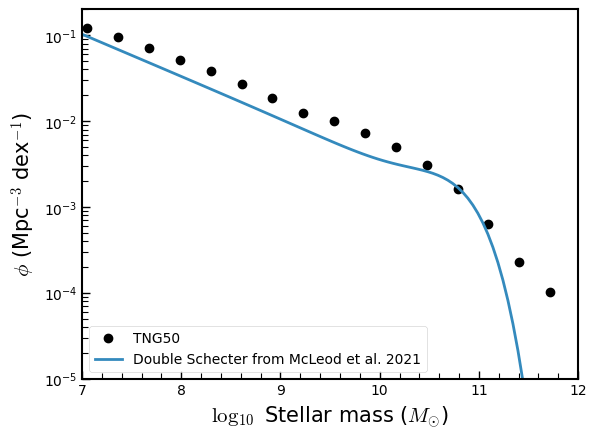

In [44]:
# first we compute the log of the stellar mass (PartType04 en este caso!)
stellar_mass = subhalos_catalog['SubhaloMassInHalfRadType'][:, 4]  * (1e10 / 0.6774) # don't forget about the unit conversion!

# we avoid subhalos with 0 stellar mass
non_zero = np.where(stellar_mass > 0)
log_mass = np.log10(stellar_mass[non_zero])

counts, edges = np.histogram(log_mass, bins=25)
bin_width = edges[1] - edges[0]

# We know that the total comoving volume is 50**3 Mpc
norm_factor = (50)**3 * bin_width

plt.plot(0.5 * (edges[:-1] + edges[1:]), counts / norm_factor, 'o', color='black', label='TNG50')
plt.plot(np.linspace(7, 12,100), double_schecter_function(10**(-2.67), 10**(-3.07), 10.51, 0.08, -1.49, np.linspace(7, 12,100))
        , label='Double Schecter from McLeod et al. 2021')
plt.ylim(1e-5, 2e-1)

plt.yscale('log')
plt.xlim(7, 12.)

plt.ylabel(r'$\phi$ (Mpc$^{-3}$ dex$^{-1}$)', fontsize=15)
plt.xlabel(r'$\log_{10}$ Stellar mass ($M_{\odot}$)', fontsize=15)
plt.legend(loc=3)
plt.show()

In [20]:
edges[1] - edges[0]

0.31108856

In [62]:
log_mass

array([11.652218 , 11.349858 , 11.221093 , ...,  4.5956683,  4.602045 ,
        4.5748158], dtype=float32)

In [78]:
print('hi')

hi


## Exploring the multiphase of the CGM 

Now that we have our subhalo downloaded, we will explore the gaseous properties of it. 
When stuyding the different phases of the CGM, we typically study species with different ionization energies, such that higher ionization species 
trace the hot CGM (like O VI), while low ionization species trace the cold CGM (like Mg II). 

In what follows, we will use TRIDENT to estimate the ions component of Mg II, C IV and O VI, and directly explore the temperature distribution of those species. 

In [163]:
import yt
from yt.units import kpc
import trident 
import numpy as np
from astropy.cosmology import FlatLambdaCDM
from astropy import units as u
import matplotlib.pyplot as plt
import plotting_setup

In [ ]:
def fit_delta_crit(x):
    # Extracted from Bryan 1998 (fit with Omega_R = 0)
    return 18*np.pi**2 + 82*x - 39*(x**2)

def virial_radius(M, z):
    # Mass has to be given in units of solar masses
    cosmo = FlatLambdaCDM(H0 = 67.74, Om0=0.3089, Ob0=0.0486)
    density = fit_delta_crit(cosmo.Om(z) - 1) * cosmo.critical_density(z)
    
    # density = 200 * cosmo.critical_density(z)  use this to use typical TNG definition of the virial radius

    density = density.to(u.M_sun/u.kpc**3)
    r_cube = (3/(4*np.pi*density)) * (M*u.M_sun)

    return r_cube**(1/3)

In [16]:
ds = yt.load('cutout_10.hdf5') 

yt : [INFO     ] 2025-06-20 11:26:46,103 Calculating time from 5.007e-01 to be 1.855e+17 seconds
yt : [INFO     ] 2025-06-20 11:26:46,198 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-20 11:26:46,198 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-20 11:26:46,199 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-06-20 11:26:46,200 Parameters: domain_right_edge         = [35000. 35000. 35000.]
yt : [INFO     ] 2025-06-20 11:26:46,201 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-06-20 11:26:46,201 Parameters: current_redshift          = 0.9972942257819404
yt : [INFO     ] 2025-06-20 11:26:46,202 Parameters: omega_lambda              = 0.6911
yt : [INFO     ] 2025-06-20 11:26:46,202 Parameters: omega_matter              = 0.3089
yt : [INFO     ] 2025-06-20 11:26:46,203 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-06-20 11:26:46,203 Parameters: hubble_constant

In [17]:
trident.add_ion_fields(ds, ions = ['Mg II', 'C IV', 'O VI'])

yt : [INFO     ] 2025-06-20 11:27:24,404 Allocating for 3.997e+07 particles
Initializing coarse index : 100%|██████████| 82/82 [00:12<00:00,  6.76it/s]
yt : [INFO     ] 2025-06-20 11:27:36,538 Updating index_order2 from 2 to 4
Initializing refined index: 100%|██████████| 82/82 [00:18<00:00,  4.32it/s]


In [20]:
help(trident.add_ion_density_field)

Help on function add_ion_density_field in module trident.ion_balance:

add_ion_density_field(atom, ion, ds, ftype='gas', ionization_table=None, field_suffix=False, sampling_type='local', particle_type=None)
    Add ion mass density field to a yt dataset for the desired ion.
    
    .. note::
    
        The preferred method for adding ion fields to a dataset is using
        :class:`~trident.add_ion_fields`,
    
    For example, add_ion_density_field('O', 6, ds) creates a field
    called O_p5_density for dataset ds, which represents 5-ionized
    oxygen (O plus 5 = O VI).
    
    Fields are added assuming collisional ionization equilibrium and
    photoionization in the optically thin limit from a redshift-dependent
    metagalactic ionizing background using the ionization_table specified.
    
    **Parameters**
    
    :atom: string
    
        Atomic species for desired ion fraction (e.g. 'H', 'C', 'Mg')
    
    :ion: integer
    
        Ion number for desired species (e.g.

In [444]:
center=(26837.2, 3214.44, 6838.29) 

masked_data = ds.sphere(center=center*ds.length_unit, radius=(200, 'kpc'))

In [96]:
mg_ii_num_density = masked_data[('gas', 'Mg_p1_number_density')].to('1/cm**3')
c_iv_num_density = masked_data[('gas', 'C_p3_number_density')].to('1/cm**3')
o_vi_num_density = masked_data[('gas', 'O_p5_number_density')].to('1/cm**3')

temperature = masked_data[('PartType0', 'temperature')]

In [117]:
mask_mgii = mg_ii_num_density > 0
mask_civ = c_iv_num_density > 0
mask_ovi = o_vi_num_density > 0

In [129]:
# Computing a mean temperature weighted by mass

mean_mgii = np.sum(masked_data[('gas', 'Mg_p1_mass')] * temperature)/np.sum(masked_data[('gas', 'Mg_p1_mass')])
mean_civ = np.sum(masked_data[('gas', 'C_p3_mass')] * temperature)/np.sum(masked_data[('gas', 'C_p3_mass')])
mean_ovi = np.sum(masked_data[('gas', 'O_p5_mass')] * temperature)/np.sum(masked_data[('gas', 'O_p5_mass')])

In [130]:
print('Mean temperature for Mg II: {:.2e}'.format(mean_mgii))
print('Mean temperature for C IV: {:.2e}'.format(mean_civ))
print('Mean temperature for O VI: {:.2e}'.format(mean_ovi))

Mean temperature for Mg II: 1.37e+04 K
Mean temperature for C IV: 7.73e+04 K
Mean temperature for O VI: 4.60e+05 K


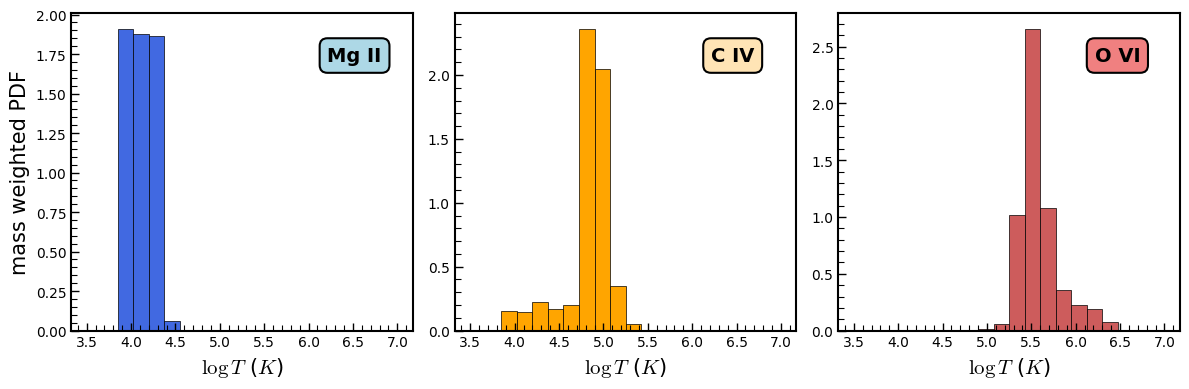

In [196]:
bins = np.linspace(3.5, 7, 21)
plt.figure(figsize=(12, 4))

# Subplot 1: Mg II
plt.subplot(131)
plt.hist(np.log10(temperature.value), weights=masked_data[('gas', 'Mg_p1_mass')].value,
            density=True, bins=bins, edgecolor='black', facecolor='royalblue')
plt.xlabel(r'$\log T$ ($K$)', fontsize=15)
plt.ylabel('mass weighted PDF', fontsize=15)
plt.text(0.75, 0.85, 'Mg II', transform=plt.gca().transAxes,
            bbox=dict(boxstyle="round,pad=0.4", facecolor='lightblue', edgecolor='black', alpha=1, linewidth=1.5), weight='bold', fontsize=14)

# Subplot 2: C IV
plt.subplot(132)
plt.hist(np.log10(temperature.value), weights=masked_data[('gas', 'C_p3_mass')].value,
            density=True, bins=bins, edgecolor='black', facecolor='orange')
plt.xlabel(r'$\log T$ ($K$)', fontsize=15)
plt.text(0.75, 0.85, 'C IV', transform=plt.gca().transAxes,
            bbox=dict(boxstyle="round,pad=0.4", facecolor='moccasin', edgecolor='black', alpha=1, linewidth=1.5), weight='bold', fontsize=14)

# Subplot 3: O VI
plt.subplot(133)
plt.hist(np.log10(temperature.value), weights=masked_data[('gas', 'O_p5_mass')].value,
            density=True, bins=bins, edgecolor='black', facecolor='indianred')
plt.xlabel(r'$\log T$ ($K$)', fontsize=15)
plt.text(0.75, 0.85, 'O VI', transform=plt.gca().transAxes,
            bbox=dict(boxstyle="round,pad=0.4", facecolor='lightcoral', edgecolor='black', alpha=1, linewidth=1.5), weight='bold', fontsize=14)

plt.tight_layout()
plt.show()

## Inflowing and outflowing gas

In [418]:
coordinates_sphere = masked_data[('PartType0', 'Coordinates')]
rel_coordinates = coordinates_sphere - np.array([26837.2, 3214.44, 6838.29]) * ds.length_unit
radius = np.sqrt(np.sum(rel_coordinates**2, axis=1))

velocity_halo = [101.351, -152.24, -21.4404] * (ds.length_unit/ds.time_unit)

In [201]:
ds.derived_field_list

[('PartType0', 'C_density'),
 ('PartType0', 'C_fraction'),
 ('PartType0', 'C_mass'),
 ('PartType0', 'C_nuclei_density'),
 ('PartType0', 'C_number_density'),
 ('PartType0', 'CenterOfMass'),
 ('PartType0', 'Coordinates'),
 ('PartType0', 'Density'),
 ('PartType0', 'El_number_density'),
 ('PartType0', 'ElectronAbundance'),
 ('PartType0', 'EnergyDissipation'),
 ('PartType0', 'Fe_density'),
 ('PartType0', 'Fe_fraction'),
 ('PartType0', 'Fe_mass'),
 ('PartType0', 'Fe_nuclei_density'),
 ('PartType0', 'Fe_number_density'),
 ('PartType0', 'GFM_AGNRadiation'),
 ('PartType0', 'GFM_CoolingRate'),
 ('PartType0', 'GFM_Metallicity'),
 ('PartType0', 'GFM_MetalsTagged'),
 ('PartType0', 'GFM_Metals_00'),
 ('PartType0', 'GFM_Metals_01'),
 ('PartType0', 'GFM_Metals_02'),
 ('PartType0', 'GFM_Metals_03'),
 ('PartType0', 'GFM_Metals_04'),
 ('PartType0', 'GFM_Metals_05'),
 ('PartType0', 'GFM_Metals_06'),
 ('PartType0', 'GFM_Metals_07'),
 ('PartType0', 'GFM_Metals_08'),
 ('PartType0', 'GFM_Metals_09'),
 ('PartT

In [419]:
rel_velocity = masked_data[('PartType0', 'Velocities')].to('km/s') - velocity_halo

dot_prod = np.sum(rel_velocity * rel_coordinates, axis=1)
norm_vel = np.sqrt(np.sum(rel_velocity**2, axis=1))
norm_position = np.sqrt(np.sum(rel_coordinates**2, axis=1))

cos_angle = dot_prod / (norm_vel * norm_position) 

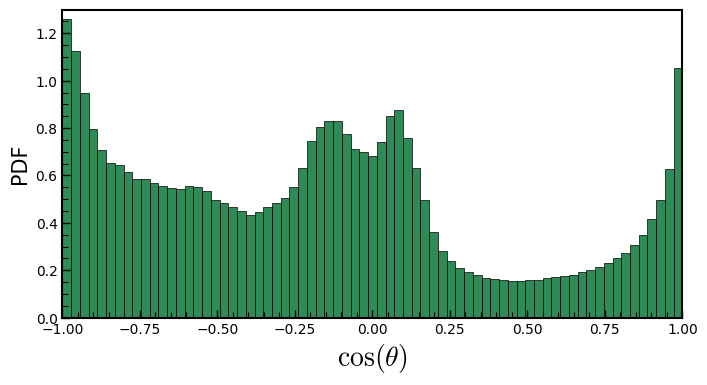

In [420]:
plt.figure(figsize=(8,4))
plt.hist(cos_angle, bins=71, edgecolor='black', density=True, facecolor='seagreen')
plt.xlabel(r'$\cos(\theta)$', fontsize=20)
plt.ylabel('PDF', fontsize=15)
plt.ylim(0, 1.3)
plt.xlim(-1,1)
plt.show()

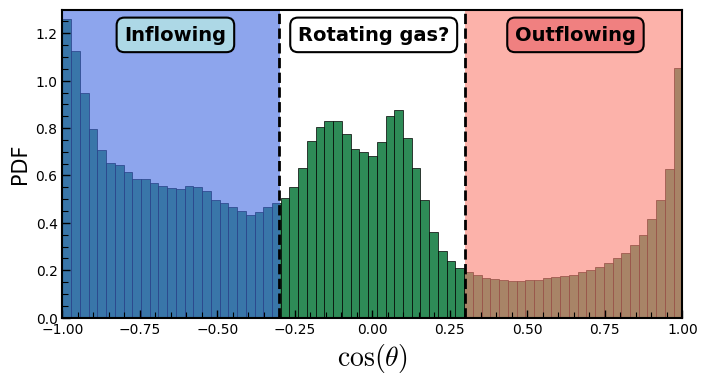

In [421]:
plt.figure(figsize=(8,4))
plt.hist(cos_angle, bins=71, edgecolor='black', density=True, facecolor='seagreen')
plt.xlabel(r'$\cos(\theta)$', fontsize=20)
plt.ylabel('PDF', fontsize=15)

plt.vlines([-0.3, 0.3], [0,0], [1.3,1.3], linestyles='--', color='black')
plt.fill_between([-1, -0.3], 0, 1.3, color='royalblue', alpha=0.6)
plt.fill_between([0.3, 1], 0, 1.3, color='salmon', alpha=0.6)

plt.text(0.1, 0.90, 'Inflowing', transform=plt.gca().transAxes,
            bbox=dict(boxstyle="round,pad=0.4", facecolor='lightblue', edgecolor='black', alpha=1, linewidth=1.5), weight='bold', fontsize=14)


plt.text(0.73, 0.90, 'Outflowing', transform=plt.gca().transAxes,
            bbox=dict(boxstyle="round,pad=0.4", facecolor='lightcoral', edgecolor='black', alpha=1, linewidth=1.5), weight='bold', fontsize=14)

plt.text(0.38, 0.90, 'Rotating gas?', transform=plt.gca().transAxes,
            bbox=dict(boxstyle="round,pad=0.4", facecolor='white', edgecolor='black', alpha=1, linewidth=1.5), weight='bold', fontsize=14)

plt.xlim(-1,1)
plt.ylim(0, 1.3)
plt.show()

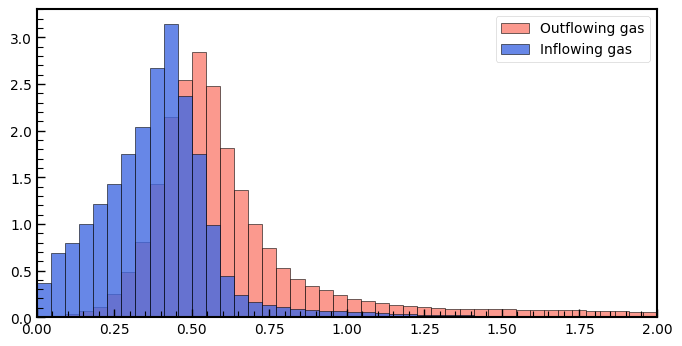

In [422]:
outflowing_gas = cos_angle > 0.3   # threshold 
inflowing_gas = cos_angle < -0.3 

bins = np.linspace(0,2, 45)

plt.figure(figsize=(8,4))

plt.hist(masked_data[('PartType0', 'GFM_Metallicity')][outflowing_gas]/0.0127, bins = bins, edgecolor='black', 
            density=True, alpha=0.8, facecolor='salmon', label='Outflowing gas')
plt.xlim(0,2)

plt.hist(masked_data[('PartType0', 'GFM_Metallicity')][inflowing_gas]/0.0127, bins=bins, edgecolor='black', 
            density=True, alpha=0.8, facecolor='Royalblue', label='Inflowing gas')
plt.xlim(0,2)

plt.legend()
plt.show()

Finally, we are going to compute the mass loading factor of this galaxy using only the **CGM gas**. 

To this end, we are going to compute the instantaneous radial mass flux as

$$\dot{M} = \frac{1}{\Delta r} \sum_{i} \left( \frac{\bold{v}_i \cdot \bold{r}_i}{|\bold{r_i}|} m_i\right) $$

where the summation index goes for all the gas cells within a spherical shell of thickness of $\Delta r$. 

Notice again, that both the velocity and coordinates are relative. 

Finally, the mass loading factor is simply $\eta = \dot{M}/SFR$. 

In [399]:
inner_cgm_radius = 10 * kpc
outer_cgm_radius = 50 * kpc
delta_r = outer_cgm_radius - inner_cgm_radius

mask_radius = (radius.to('kpc') > inner_cgm_radius) * (radius.to('kpc') < outer_cgm_radius)

outflowing_gas = cos_angle > 0.   # relaxed this time 
inflowing_gas = cos_angle < 0 

mask_outflow = outflowing_gas * mask_radius
mask_inflow = inflowing_gas * mask_radius

In [401]:
# We compute some values before hand :) 

vel_pos_dot_prod = np.sum(rel_velocity[mask_outflow] * rel_coordinates[mask_outflow], axis=1)
norm_position = np.sqrt(np.sum(rel_coordinates[mask_outflow]**2, axis=1))
masses = masked_data[('PartType0', 'Masses')].to('Msun')[mask_outflow]

# now M_dot 

M_dot = (1/delta_r) * np.sum(vel_pos_dot_prod * masses/ norm_position )

M_dot.to('Msun/yr')

unyt_quantity(54.54353233, 'Msun/yr')

In [396]:
masses 

unyt_array([135596.49031145, 124107.10020795,  97248.74425599, ...,
             74570.33051738,  87597.51232868,  61797.71818553], 'Msun')

In [398]:
np.sum(masses * (vel_pos_dot_prod/norm_position))

unyt_quantity(1.50587972e+12, 'Msun*km/s')

In [390]:
masked_data[('PartType0', 'Masses')].to('Msun')

unyt_array([ 85060.21812548, 123113.41299004,  76341.33096832, ...,
             87597.51232868,  61797.71818553,  99930.09080615], 'Msun')

In [388]:
# We compute some values before hand :) 

vel_pos_dot_prod = np.sum(rel_velocity[mask_inflow] * rel_coordinates[mask_inflow], axis=1)
norm_position = np.sqrt(np.sum(rel_coordinates[mask_inflow]**2, axis=1))
masses = masked_data[('PartType0', 'Masses')][mask_inflow]

# now M_dot 

M_dot = (1/delta_r) * np.sum(vel_pos_dot_prod * masses/ norm_position )

M_dot.to('Msun/s')

unyt_quantity(-2.96774355e-06, 'Msun/s')

In [425]:
center

(26837.2, 3214.44, 6838.29)

In [445]:
radius_stars = np.sqrt(np.sum((masked_data[('PartType4', 'Coordinates')] - center * ds.length_unit)**2, axis=1))

mask_stars_radius = radius_stars.to('kpc') < 10 * kpc  
velocities_stars = np.sqrt(np.sum((masked_data[('PartType4', 'Velocities')].to('km/s') - velocity_halo)**2, axis=1))

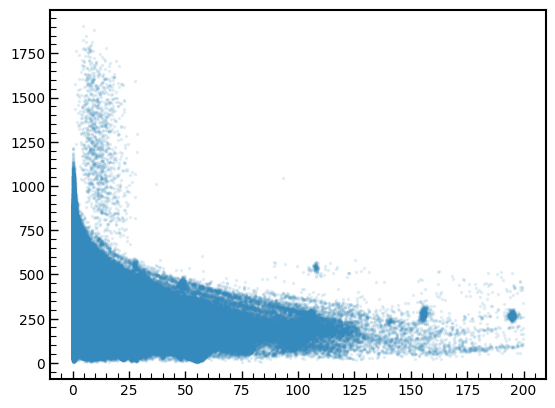

In [450]:
plt.plot(radius_stars.to('kpc'), velocities_stars, 'o', markersize=1.5, alpha=0.1)
plt.show()

## Column density visualizations

yt : [INFO     ] 2025-06-20 19:49:27,692 xlim = 26803.375827 26871.024173
yt : [INFO     ] 2025-06-20 19:49:27,694 ylim = 3180.615827 3248.264173
yt : [INFO     ] 2025-06-20 19:49:27,695 xlim = 26803.375827 26871.024173
yt : [INFO     ] 2025-06-20 19:49:27,695 ylim = 3180.615827 3248.264173
yt : [INFO     ] 2025-06-20 19:49:27,697 Making a fixed resolution buffer of (('gas', 'Mg_p1_number_density')) 800 by 800
yt : [WARNING  ] 2025-06-20 19:49:36,901 Plotting ('gas', 'Mg_p1_number_density'): Both positive and negative values. Min = 0.0 cm**(-2), Max = 5.018206380451353e+17 cm**(-2).
yt : [WARNING  ] 2025-06-20 19:49:36,902 Switching to symlog colorbar scaling.



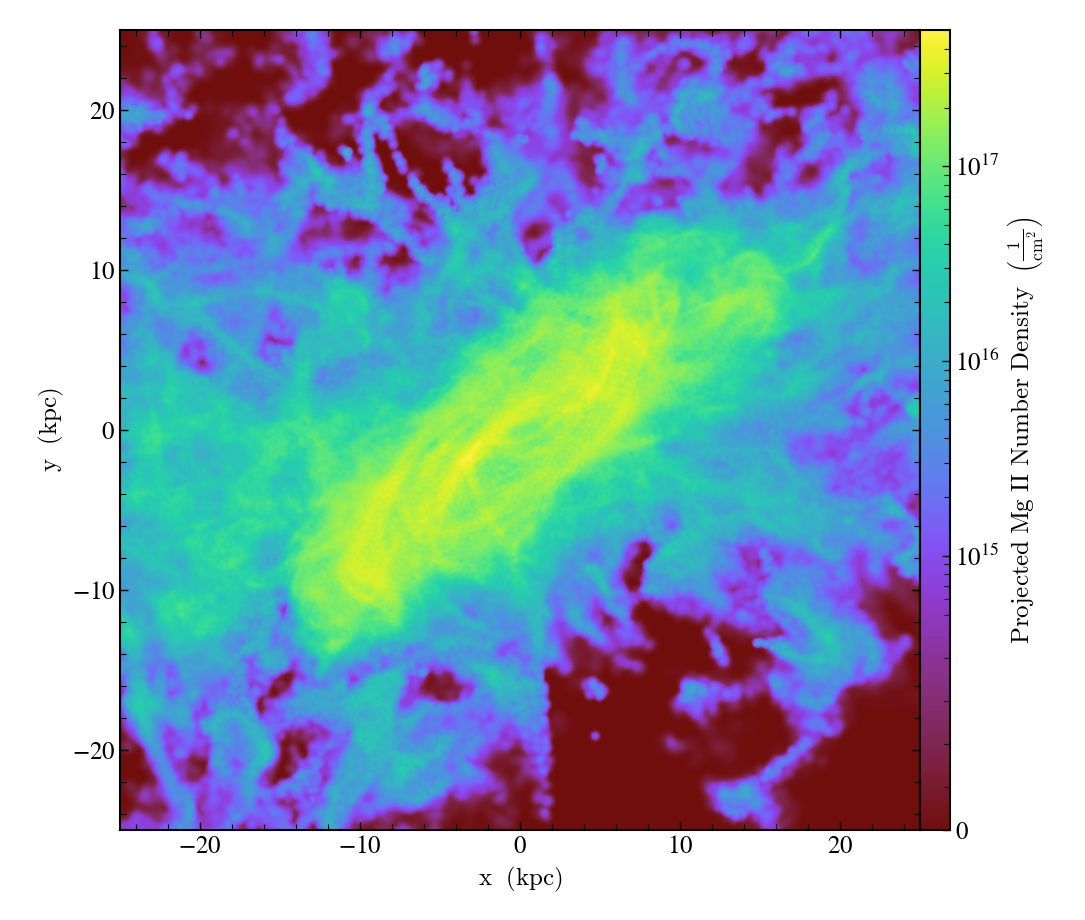

In [407]:
yt.ProjectionPlot(ds, 'z', ('gas', 'Mg_p1_number_density'), center=center, width=(50,'kpc'), data_source=masked_data)

In [410]:
yt.ProjectionPlot(ds, 'z', ('PartType4', 'Masses'), center=center, width=(50,'kpc'), data_source=masked_data)

YTInvalidFieldType: 
SlicePlot, ProjectionPlot, and OffAxisProjectionPlot can only plot fields that
are defined on a mesh or for SPH particles, but received the following N-body
particle fields:

    [('PartType4', 'Masses')]

Did you mean to use ParticlePlot or plot a deposited particle field instead?

yt : [INFO     ] 2025-06-20 19:48:24,180 xlim = 26803.375827 26871.024173
yt : [INFO     ] 2025-06-20 19:48:24,180 ylim = 3180.615827 3248.264173
yt : [INFO     ] 2025-06-20 19:48:24,182 xlim = 26803.375827 26871.024173
yt : [INFO     ] 2025-06-20 19:48:24,182 ylim = 3180.615827 3248.264173
yt : [INFO     ] 2025-06-20 19:48:24,185 Making a fixed resolution buffer of (('gas', 'Mg_p1_number_density')) 800 by 800



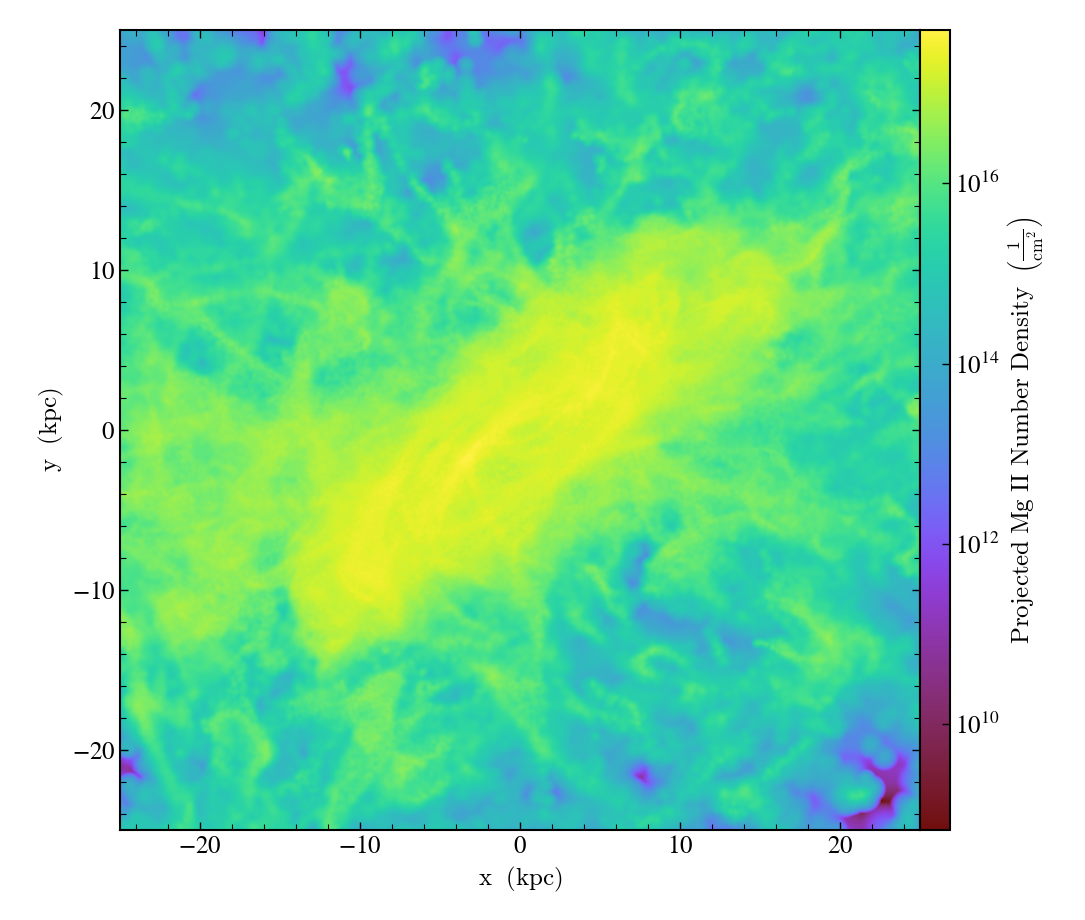

In [405]:
yt.ProjectionPlot(ds, 'z', ('gas', 'Mg_p1_number_density'), center=center, width=(50,'kpc'), data_source=masked_data)

### DLAs covering fraction

# Useful references and links

- [TNG project website](https://www.tng-project.org)
- [CGM lectures summary including basic tutorials on TNG simulations](https://arxiv.org/pdf/2411.07988)
- [All TNG-related papers](https://www.tng-project.org/results/)
- [TNG Web-browsable Data access API](https://www.tng-project.org/api/)
- [TNG tutorials on how to access the data](https://www.tng-project.org/data/docs/api/)